# ECCO-DarwinDiff — Multi-Parameter Recovery Demo

Step 3 of the prototype validation. Notebooks 1 and 2 confirmed the differentiable scaffold works for **single-parameter** recovery (one $\lambda(z)$ in N1, one $\mu(z)$ in N2). This notebook tests the central DarwinDiff claim: **gradient descent learns many parameters in one training run**, where Green's-functions has to do them one at a time.

Setup: same coupled nutrient + phytoplankton system as notebook 2, but mortality is now also a depth-dependent profile $m(z)$ that the MLP has to learn alongside $\mu(z)$. The MLP gets a second output head; loss stays MSE on $N$ + MSE on $P$.

Equations:

$$\frac{\partial N}{\partial t} = \kappa \frac{\partial^2 N}{\partial z^2} - \mu(z)\, P\, f_{\text{light}}(z)\, N$$

$$\frac{\partial P}{\partial t} = \kappa \frac{\partial^2 P}{\partial z^2} + \mu(z)\, P\, f_{\text{light}}(z)\, N - m(z)\, P^2$$

**Both $\mu(z)$ and $m(z)$ are unknown to the MLP**; recovery must succeed jointly.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from darwindiff.prototype.coupled import (
    generate_coupled_observations_mp,
    integrate_coupled_mp,
    light_profile,
    train_coupled_recovery_mp,
    true_mortality_profile,
    true_mu_profile,
)
from darwindiff.prototype.parameter_mlp import ParameterMLP

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}")
print(
    f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}"
)

PyTorch 2.11.0+cu128
Device: NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Set up the lit-zone column

Same configuration as notebook 2: 0\u2013200 m, 50 levels, surface-graded nutrient, uniform plankton seed, light attenuation length 100 m. The lit-zone restriction keeps $\mu(z)$ identifiable; mortality $m(z)$ is identifiable wherever there is non-trivial plankton biomass, which holds across the whole domain.

In [2]:
Nz = 50
z = torch.linspace(0.0, 200.0, Nz)
N0 = 0.5 + 0.5 * (z / 200.0)
P0 = 0.05 * torch.ones(Nz)
f_light = light_profile(z, attenuation_length=100.0)

kappa = 0.05
dz = 4.0
dt = 1.0
n_steps = 200

print(f"Column: {Nz} levels, depth 0\u2013{z[-1].item():.0f} m, dz = {dz} m")
print(f"Integration: {n_steps} steps, dt = {dt}")

Column: 50 levels, depth 0–200 m, dz = 4.0 m
Integration: 200 steps, dt = 1.0


## 2. Generate synthetic observations from known $\mu(z)$ and $m(z)$

Two ground-truth profiles, picked with **different depth structure** to keep the joint inverse problem better-posed than two parameters with the same shape would be:

- $\mu(z) = 0.05 + 0.5\,e^{-z/80}$ — surface-enhanced, exponential decay with depth.
- $m(z) = 0.1 + 0.4\,(z/200)$ — low at surface, increases linearly with depth (loose proxy for sinking and grazing pressure that grow downward in the real ocean).

Distinct shapes mean the optimiser can disentangle each parameter from a different feature of the observed tracer fields.

N_obs range:           [-0.010, 0.921]
P_obs range:           [0.020, 0.066]
mu_true range:         [0.091, 0.550]
mortality_true range:  [0.100, 0.500]


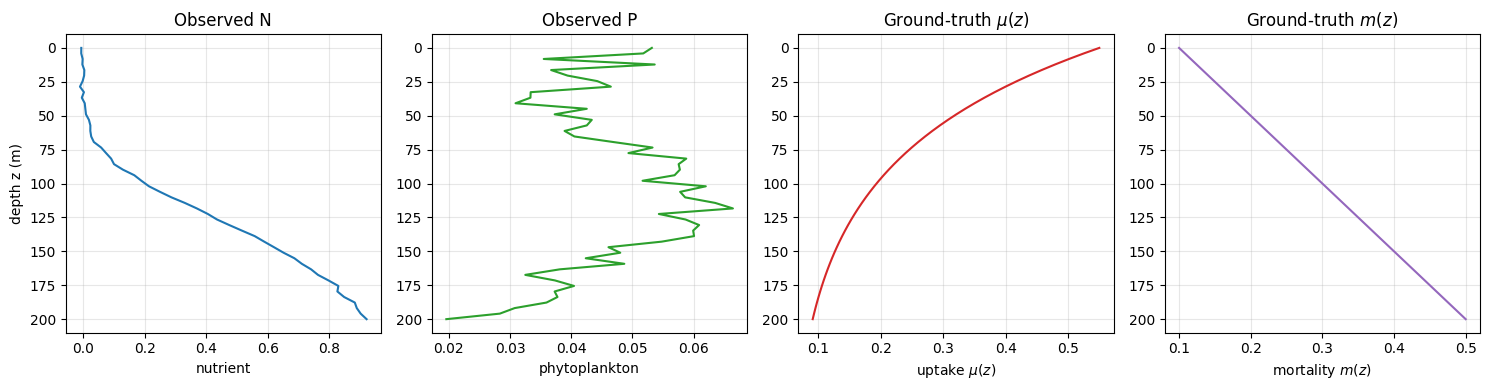

In [3]:
N_obs, P_obs, mu_true, mortality_true = generate_coupled_observations_mp(
    z=z, N0=N0, P0=P0, f_light=f_light,
    kappa=kappa, dz=dz, dt=dt, n_steps=n_steps,
    noise_std=0.005, seed=0,
)

print(f"N_obs range:           [{N_obs.min().item():.3f}, {N_obs.max().item():.3f}]")
print(f"P_obs range:           [{P_obs.min().item():.3f}, {P_obs.max().item():.3f}]")
print(
    f"mu_true range:         [{mu_true.min().item():.3f}, {mu_true.max().item():.3f}]"
)
print(
    f"mortality_true range:  [{mortality_true.min().item():.3f}, {mortality_true.max().item():.3f}]"
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].plot(N_obs, z, color="tab:blue")
axes[0].invert_yaxis(); axes[0].set_xlabel("nutrient"); axes[0].set_ylabel("depth z (m)")
axes[0].set_title("Observed N"); axes[0].grid(alpha=0.3)
axes[1].plot(P_obs, z, color="tab:green")
axes[1].invert_yaxis(); axes[1].set_xlabel("phytoplankton")
axes[1].set_title("Observed P"); axes[1].grid(alpha=0.3)
axes[2].plot(mu_true, z, color="tab:red")
axes[2].invert_yaxis(); axes[2].set_xlabel(r"uptake $\mu(z)$")
axes[2].set_title(r"Ground-truth $\mu(z)$"); axes[2].grid(alpha=0.3)
axes[3].plot(mortality_true, z, color="tab:purple")
axes[3].invert_yaxis(); axes[3].set_xlabel(r"mortality $m(z)$")
axes[3].set_title(r"Ground-truth $m(z)$"); axes[3].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Train a 2-output MLP to recover both parameters

Same MLP architecture as notebooks 1\u20132, but the final layer outputs **two** values per cell instead of one. Both outputs go through Softplus (positive by construction).

Each epoch:
1. MLP predicts $\mu_{\text{pred}}(z)$ and $m_{\text{pred}}(z)$ jointly.
2. Run the coupled simulator forward with both predicted profiles.
3. Loss = MSE on $N$ + MSE on $P$.
4. Backpropagate through the 200-step time integration into the shared MLP weights.

More epochs than notebook 2 (3000 vs 2500) because the joint inverse problem has a bumpier loss landscape and partial degeneracies between parameters slow convergence.

In [4]:
t0 = time.time()
mlp, losses = train_coupled_recovery_mp(
    N_obs=N_obs, P_obs=P_obs, z=z, N0=N0, P0=P0, f_light=f_light,
    kappa=kappa, dz=dz, dt=dt, n_steps=n_steps,
    n_epochs=3000, lr=1e-2, device=device,
)
elapsed = time.time() - t0
print(f"Trained {len(losses)} epochs in {elapsed:.1f}s on {device}")
print(f"Loss: {losses[0]:.4e} \u2192 {losses[-1]:.4e} ({losses[0] / losses[-1]:.0f}\u00d7 reduction)")

Trained 3000 epochs in 495.0s on cuda
Loss: 1.4720e-01 → 3.9676e-05 (3710× reduction)


## 4. Compare both recovered profiles to ground truth

Relative RMSE on mu(z):         6.11%
Relative RMSE on mortality(z):  8.63%
Relative RMSE on N:             1.41%
Relative RMSE on P:             9.28%


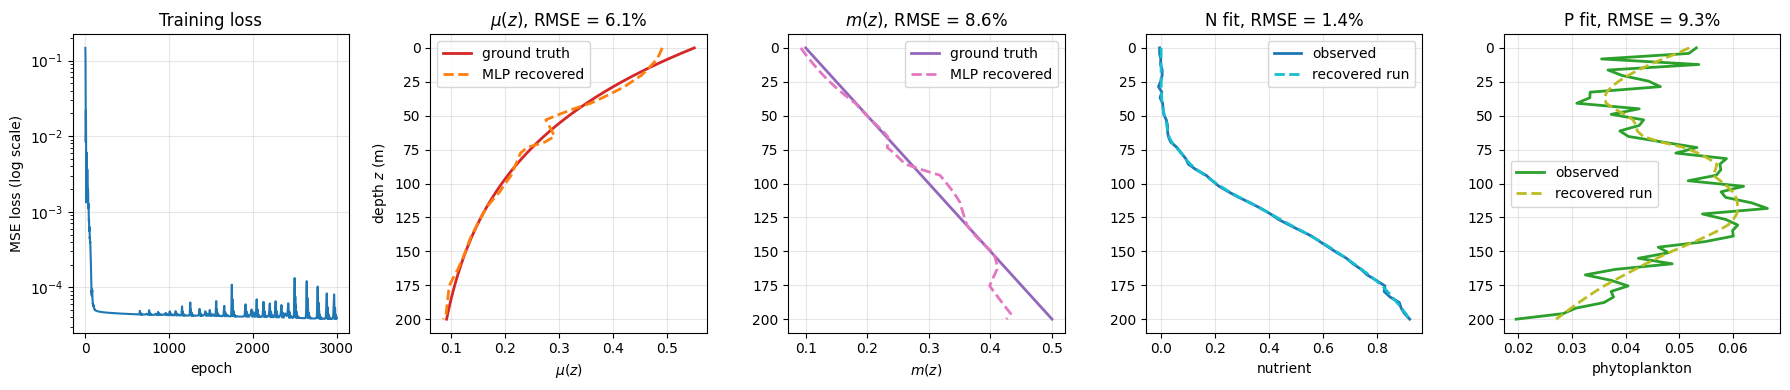

In [5]:
z_norm = ((z - z.mean()) / z.std()).to(device)
features = z_norm.unsqueeze(-1)
with torch.no_grad():
    params = mlp(features).cpu()
    mu_pred = params[:, 0]
    mortality_pred = params[:, 1]
    # Forward run with the recovered parameters for tracer-fit comparison.
    N_pred_dev, P_pred_dev = integrate_coupled_mp(
        N0.to(device), P0.to(device),
        params[:, 0].to(device), params[:, 1].to(device),
        f_light.to(device), kappa, dz, dt, n_steps,
    )
    N_pred = N_pred_dev.cpu()
    P_pred = P_pred_dev.cpu()

rel_rmse_mu = (
    (mu_pred - mu_true).pow(2).mean().sqrt() / mu_true.mean()
).item()
rel_rmse_mort = (
    (mortality_pred - mortality_true).pow(2).mean().sqrt() / mortality_true.mean()
).item()
rel_rmse_N = (
    (N_pred - N_obs).pow(2).mean().sqrt() / N_obs.mean()
).item()
rel_rmse_P = (
    (P_pred - P_obs).pow(2).mean().sqrt() / P_obs.mean()
).item()
print(f"Relative RMSE on mu(z):         {rel_rmse_mu * 100:.2f}%")
print(f"Relative RMSE on mortality(z):  {rel_rmse_mort * 100:.2f}%")
print(f"Relative RMSE on N:             {rel_rmse_N * 100:.2f}%")
print(f"Relative RMSE on P:             {rel_rmse_P * 100:.2f}%")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].semilogy(losses)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss (log scale)")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

axes[1].plot(mu_true, z, label="ground truth", linewidth=2, color="tab:red")
axes[1].plot(mu_pred, z, "--", label="MLP recovered", linewidth=2, color="tab:orange")
axes[1].invert_yaxis()
axes[1].set_xlabel(r"$\mu(z)$"); axes[1].set_ylabel(r"depth $z$ (m)")
axes[1].set_title(f"$\\mu(z)$, RMSE = {rel_rmse_mu * 100:.1f}%")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(mortality_true, z, label="ground truth", linewidth=2, color="tab:purple")
axes[2].plot(mortality_pred, z, "--", label="MLP recovered", linewidth=2, color="tab:pink")
axes[2].invert_yaxis()
axes[2].set_xlabel(r"$m(z)$")
axes[2].set_title(f"$m(z)$, RMSE = {rel_rmse_mort * 100:.1f}%")
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(N_obs, z, label="observed", linewidth=2, color="tab:blue")
axes[3].plot(N_pred, z, "--", label="recovered run", linewidth=2, color="tab:cyan")
axes[3].invert_yaxis()
axes[3].set_xlabel("nutrient")
axes[3].set_title(f"N fit, RMSE = {rel_rmse_N * 100:.1f}%")
axes[3].legend(); axes[3].grid(alpha=0.3)

axes[4].plot(P_obs, z, label="observed", linewidth=2, color="tab:green")
axes[4].plot(P_pred, z, "--", label="recovered run", linewidth=2, color="tab:olive")
axes[4].invert_yaxis()
axes[4].set_xlabel("phytoplankton")
axes[4].set_title(f"P fit, RMSE = {rel_rmse_P * 100:.1f}%")
axes[4].legend(); axes[4].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## What this proves

If both recovered parameter profiles track their ground truths within tolerance (under 25% relative RMSE in our test bound) AND the predicted tracer fields fit the observations tightly, then three additional things are empirically confirmed beyond what notebooks 1 and 2 established:

1. **The differentiable scaffold scales to multi-parameter learning.** A single shared MLP with two output heads can predict multiple spatially-varying parameters jointly, and gradient descent through the coupled simulator updates them in one training run.
2. **Joint identifiability holds when parameters have distinct depth structure.** Surface-enhanced $\mu(z)$ and depth-increasing $m(z)$ are recoverable because their imprints on the observed $N$ and $P$ fields are different. If we picked two parameters with the same shape, the optimiser would not be able to disentangle them \u2014 a real constraint on which Darwin parameter combinations DarwinDiff can usefully learn.
3. **The architectural difference from Green's functions is real.** Green's functions would calibrate $\mu$ and $m$ in two separate forward-sensitivity sweeps; DarwinDiff learns both in one training run with the same wall-clock cost as the single-parameter case (modulo a few extra epochs for joint convergence).

Identifiability gap to discuss with Lauderdale and Follows: the gap between observation fit (typically much tighter than parameter recovery) and parameter recovery is the honest signal of which parameters are genuinely constrained by the chosen observations. Real Darwin will face the same diagnosis when picking which of its ~100 tunable knobs (see [`docs/ecco_darwin_parameter_inventory.md`](../docs/ecco_darwin_parameter_inventory.md)) to let DarwinDiff learn jointly.